# 1. Project Objective

# Duolingo, Inc. — NASDAQ: DUOL
**FIN 43900 Weeks 5–6 | Valuation date: September 21, 2026 close**

Build and audit a linked pro-forma valuation, then test what drives its result. Financial amounts and share counts are in **millions**, except per-share prices. This is an educational analysis, not investment advice.

The visible check blocks in Sections 9, 12 and 24 gate valuation. The original workspace files were preserved. All calculations use frozen public-source snapshots so the notebook runs offline.

In [1]:
from pathlib import Path
import sys, json, copy
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image
project_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd() / "duol_valuation"
sys.path.insert(0, str(project_root))
from src.data_loader import ROOT, load_data, price_data
from src.historical_analysis import analyze
from src.beta import estimate
from src.assumptions import build_assumptions, unpack
from src.forecast import project
from src.checks import run_model_checks, require_pass, display_checks
from src.valuation import dcf
from src.sensitivity import sensitivities, rerun
from src.implied_expectations import solve_implied
from src.validation import broken_tests, independent_audit
from src.abg_validation import validate_abg
from src.pipeline import IS, BS, CF, terminal_variants
from src.charts import make_charts
pd.options.display.float_format = '{:,.4f}'.format
pd.options.display.max_rows = 160


## 2. Course Methodology

The [ABG tutorial](https://github.com/CinderZhang/FIN43900-Fall2026/blob/main/lessons/week-05/pro-forma-abg-tutorial.md) was reviewed before model construction: both slide decks, full spoken notes and VTT captions. YouTube links opened but audiovisual playback was unavailable.

Process: source three years → label inputs → build one year in statement order → calculate cash last → enforce checks → deliberately break the model → expand to five years → value → measure beta → seven rates → shocks and joint cases → price-implied assumptions → present.

ABG uses FCFE because floor-plan borrowing is integral to a dealer. DUOL uses FCFF/WACC, with no traditional debt and leases treated as operating throughout. Its funding advantage is prepaid subscription revenue, not inventory loans. The reference calculations below use Lab09?s exact 17.951349m share count and match the $291.75 base to cents, with scenario tolerances matching the displayed decimal precision.

In [2]:
abg = validate_abg()
display(abg)

,test,calculated,course_answer,tolerance,status
0,Base,291.7517,291.7500,0.0050,PASS
1,GM down,256.1215,256.1000,0.0510,PASS
2,GM up,327.3818,327.4000,0.0510,PASS
3,Capex up,258.3062,258.3000,0.0510,PASS
4,Capex down,325.1971,325.2000,0.0510,PASS
5,Growth down,270.1639,270.2000,0.0510,PASS
6,Growth up,314.1040,314.1000,0.0510,PASS
7,Named downside,210.0433,210.0000,0.0510,PASS
8,Implied r,0.1382,0.1382,0.0010,PASS
9,Implied gm,0.1408,0.1408,0.0010,PASS


## 3. Duolingo Overview

Duolingo monetizes a large free learning audience through paid subscriptions, advertising, English tests and in-app purchases. Subscription revenue represented 84.2% of FY2025 revenue. Engagement and conversion matter, but paid subscribers are a period-end count while revenue is earned throughout the year.

The model therefore anchors total revenue to management guidance, uses subscriber/MAU/DAU history as a diagnostic, and avoids fabricating churn, ARPU or a causal user-to-revenue forecast. Deferred revenue provides funding; deferred platform fees partially offset it. R&D, marketing, SBC and AI delivery costs shape margins.

## 4. Data Sources

Historical statements: FY2025 10-K and FY2024 comparative balances, cross-checked against SEC companyfacts. H1 actuals: Q2 2026 10-Q. Guidance: Q2 shareholder letter pp10–11. Prices: Yahoo, with Nasdaq confirming the selected close. Treasury/ERP: Damodaran September 1 snapshot. The latest completed closing price is used instead of the partial September 22 trading session.

Exact accession and tag provenance is in `data/processed/source_ledger.csv`; original file inventory and course snapshots are in `data/raw`. Failed Treasury/FRED requests are disclosed; no September 21 yield was invented.

In [3]:
history, interim = load_data()
prices, market_price = price_data()
beta_statistics, returns = estimate(prices)
assumptions = build_assumptions(history, beta_statistics.iloc[0].beta)
inputs = unpack(assumptions)
display(pd.DataFrame([{'valuation_date':'2026-09-21','DUOL_close':market_price,'financial_anchor':'2026-06-30','rate_input_vintage':'2026-09-01'}]))
display(pd.read_csv(ROOT / 'data/processed/source_ledger.csv').head(12))

,valuation_date,DUOL_close,financial_anchor,rate_input_vintage
0,2026-09-21,149.4200,2026-06-30,2026-09-01


,metric,end,start,value,source,tag
0,RevenueFromContractWithCustomerExcludingAssess...,2023-12-31,2023-01-01,531.1090,SEC 0001628280-26-012494 (2026-02-27); company...,RevenueFromContractWithCustomerExcludingAssess...
1,CostOfRevenue,2023-12-31,2023-01-01,142.1050,SEC 0001628280-26-012494 (2026-02-27); company...,CostOfRevenue
2,GrossProfit,2023-12-31,2023-01-01,389.0040,SEC 0001628280-26-012494 (2026-02-27); company...,GrossProfit
3,ResearchAndDevelopmentExpense,2023-12-31,2023-01-01,194.3520,SEC 0001628280-26-012494 (2026-02-27); company...,ResearchAndDevelopmentExpense
4,SellingAndMarketingExpense,2023-12-31,2023-01-01,75.7880,SEC 0001628280-26-012494 (2026-02-27); company...,SellingAndMarketingExpense
5,GeneralAndAdministrativeExpense,2023-12-31,2023-01-01,132.1230,SEC 0001628280-26-012494 (2026-02-27); company...,GeneralAndAdministrativeExpense
6,OperatingExpenses,2023-12-31,2023-01-01,402.2630,SEC 0001628280-26-012494 (2026-02-27); company...,OperatingExpenses
7,OperatingIncomeLoss,2023-12-31,2023-01-01,-13.2590,SEC 0001628280-26-012494 (2026-02-27); company...,OperatingIncomeLoss
8,InterestIncomeOperating,2023-12-31,2023-01-01,31.0910,SEC 0001628280-26-012494 (2026-02-27); company...,InterestIncomeOperating
9,NonoperatingIncomeExpense,2023-12-31,2023-01-01,-0.0550,SEC 0001628280-26-012494 (2026-02-27); company...,NonoperatingIncomeExpense


## 5. Historical Financial Statements

Fiscal years ended December 31, 2023–2025. The cash-flow capex definition includes **both PPE and capitalized software/intangibles**; it excludes acquisitions. The 2025 tax benefit is exceptional and is not a sustainable operating margin.

In [4]:
display(history[IS].T)
display(history[BS].T)
display(history[['cfo','cfi','cff','capex_ppe','capex_software','sbc','da','investment_purchases','investment_maturities','options_proceeds','withholding','share_repurchases','cf_deferred_revenue_increase','cf_ar_increase','cf_deferred_cost_increase','cf_ap_increase','cf_accrued_increase','basic_shares','diluted_shares']].T)

year,2023,2024,2025
revenue,531.1090,748.0240,"1,037.5890"
cost_of_revenue,142.1050,203.6450,288.1320
gross_profit,389.0040,544.3790,749.4570
rd,194.3520,235.2980,306.3230
sm,75.7880,90.4940,125.6770
ga,132.1230,155.9920,181.8870
opex,402.2630,481.7840,613.8870
ebit,-13.2590,62.5950,135.5700
interest_income,31.0910,42.6970,45.2310
other_net,-0.0550,-2.9860,1.6090


year,2023,2024,2025
cash,747.6100,785.7910,"1,036.3890"
short_investments,0.0000,91.8540,104.0780
long_investments,0.0000,98.2920,135.0980
ar,88.9750,128.9230,162.8270
deferred_cost,53.9310,80.1620,102.6630
prepaid,7.2820,14.8310,16.5820
tax_receivable,0.0000,0.0270,14.0670
ppe,11.7920,18.9430,36.2970
intangibles,15.9950,19.8990,28.3090
rou,19.1030,47.4950,80.3800


year,2023,2024,2025
cfo,153.6140,285.5130,387.8230
cfi,-13.5840,-217.3300,-107.6780
cff,2.1350,-30.0020,-29.5470
capex_ppe,3.1910,12.1160,18.0960
capex_software,10.4930,9.0240,9.3030
sbc,95.2210,110.4770,137.4370
da,7.0950,10.8540,14.3910
investment_purchases,0.0000,193.3000,162.9260
investment_maturities,0.0000,3.7050,115.7470
options_proceeds,13.6170,19.3560,12.5700


## 6. Historical Analysis

All ratios are computed from the tables above. Growth for the first historical year is intentionally unavailable because this presentation uses three annual years. MAU/DAU are Q4 averages and paid subscribers are year-end counts. Revenue divided by year-end subscribers is a **monetization proxy, not ARPU**. Negative working capital reflects customer prepayments, not a missing asset.

Q2 2026 provides a recent diagnostic: 58.7m DAU (+23%), 140.6m MAU (+10%), 12.7m paid subscribers (+17%), $289.1m bookings (+8%) and $258.035m subscription revenue (+22%). These differing growth rates caution against extrapolating user growth directly into revenue.

In [5]:
historical_ratios, operating_kpis = analyze(history)
display(historical_ratios.T)
display(operating_kpis.T)

year,2023,2024,2025
revenue_growth,NaN,0.4084,0.3871
gross_profit_to_revenue,0.7324,0.7278,0.7223
ebit_to_revenue,-0.0250,0.0837,0.1307
rd_to_revenue,0.3659,0.3146,0.2952
sm_to_revenue,0.1427,0.1210,0.1211
ga_to_revenue,0.2488,0.2085,0.1753
sbc_to_revenue,0.1793,0.1477,0.1325
da_to_revenue,0.0134,0.0145,0.0139
capex_to_revenue,0.0258,0.0283,0.0264
deferred_revenue_to_revenue,0.4692,0.4985,0.4782


year,2023,2024,2025
mau,88.4000,116.7000,133.1000
dau,26.9000,40.5000,52.7000
paid_subscribers,6.6000,9.5000,12.2000
bookings,622.1810,870.6010,"1,158.4250"
subscription_bookings,495.4970,730.7370,996.2680
subscription_revenue,404.6840,607.5310,873.4420
mau_growth,NaN,0.3201,0.1405
dau_growth,NaN,0.5056,0.3012
paid_subscribers_growth,NaN,0.4394,0.2842
bookings_growth,NaN,0.3993,0.3306


## 7. Forecast Assumptions

**HISTORY** is a filed figure or calculated historical ratio; **GUIDANCE** is a company outlook; **JUDGMENT** is an analyst choice. The 2026 revenue outlook is $1,207m, gross margin 71.6%, SBC about 15% of revenue and tax rate 23–25% (24% selected). Later years are not company guidance.

R&D/marketing/G&A drivers exclude SBC but include embedded D&A. SBC is added once to these expenses, split 70/10/20 as a presentation convention. Cash is not forecast as a revenue ratio. Guidance range bounds are stored when disclosed; the current point revenue outlook supersedes mechanically choosing a midpoint of the earlier 15–18% range. The low/high shock columns refer to parameter direction, not necessarily valuation direction.

In [6]:
display(assumptions)
display(pd.read_csv(ROOT / "model_conventions.csv"))

,assumption_name,year,base_value,source_category,source,rationale,downside_value,upside_value,guidance_low,guidance_high,notes
0,growth,2026,0.1633,GUIDANCE,https://www.sec.gov/Archives/edgar/data/156208...,"2026 $1,207m point outlook; subsequent reaccel...",0.1333,0.1933,0.1500,0.1800,Downside/upside columns are parameter low/high...
1,growth,2027,0.1800,JUDGMENT,https://www.sec.gov/Archives/edgar/data/156208...,"2026 $1,207m point outlook; subsequent reaccel...",0.1500,0.2100,NaN,NaN,Downside/upside columns are parameter low/high...
2,growth,2028,0.1600,JUDGMENT,https://www.sec.gov/Archives/edgar/data/156208...,"2026 $1,207m point outlook; subsequent reaccel...",0.1300,0.1900,NaN,NaN,Downside/upside columns are parameter low/high...
3,growth,2029,0.1300,JUDGMENT,https://www.sec.gov/Archives/edgar/data/156208...,"2026 $1,207m point outlook; subsequent reaccel...",0.1000,0.1600,NaN,NaN,Downside/upside columns are parameter low/high...
4,growth,2030,0.1000,JUDGMENT,https://www.sec.gov/Archives/edgar/data/156208...,"2026 $1,207m point outlook; subsequent reaccel...",0.0700,0.1300,NaN,NaN,Downside/upside columns are parameter low/high...
5,gross_margin,2026,0.7160,GUIDANCE,https://www.sec.gov/Archives/edgar/data/156208...,2026 71.6% guidance; modest future recovery wi...,0.7060,0.7260,NaN,NaN,Downside/upside columns are parameter low/high...
6,gross_margin,2027,0.7200,JUDGMENT,https://www.sec.gov/Archives/edgar/data/156208...,2026 71.6% guidance; modest future recovery wi...,0.7100,0.7300,NaN,NaN,Downside/upside columns are parameter low/high...
7,gross_margin,2028,0.7300,JUDGMENT,https://www.sec.gov/Archives/edgar/data/156208...,2026 71.6% guidance; modest future recovery wi...,0.7200,0.7400,NaN,NaN,Downside/upside columns are parameter low/high...
8,gross_margin,2029,0.7400,JUDGMENT,https://www.sec.gov/Archives/edgar/data/156208...,2026 71.6% guidance; modest future recovery wi...,0.7300,0.7500,NaN,NaN,Downside/upside columns are parameter low/high...
9,gross_margin,2030,0.7400,JUDGMENT,https://www.sec.gov/Archives/edgar/data/156208...,2026 71.6% guidance; modest future recovery wi...,0.7300,0.7500,NaN,NaN,Downside/upside columns are parameter low/high...


,assumption_name,year,base_value,source_category,source,rationale,notes
0,SBC allocation to R&D,all,0.70,JUDGMENT,Analyst presentation convention,Allocates total SBC without changing total EBIT,No valuation effect holding total SBC fixed
1,SBC allocation to marketing,all,0.10,JUDGMENT,Analyst presentation convention,Allocates total SBC without changing total EBIT,No valuation effect holding total SBC fixed
2,SBC allocation to G&A,all,0.20,JUDGMENT,Analyst presentation convention,Allocates total SBC without changing total EBIT,Weights sum to one
3,D&A allocation,all,opening carrying value shares,JUDGMENT,Analyst roll-forward convention,Split total D&A between PPE and intangibles,Total D&A sensitivity separately modeled
4,Other nonoperating income,forecast,0,JUDGMENT,No recurring forecast support,Do not extrapolate volatile other gains or losses,Excluded from operating FCFF
5,New traditional borrowing,forecast,0,JUDGMENT,DUOL 10-K and interim statements,No traditional debt and no invented revolver,Financing shortfall blocks valuation
6,Investment portfolio net purchases,forecast,0,JUDGMENT,Analyst treasury simplification,Hold short and long investment balances at Jun...,Renew maturities at same balance; interest in ...
7,ROU and long-term lease balances,forecast,June 30 balances,JUDGMENT,Analyst operating-lease renewal convention,Lease cost retained in operating margins; no l...,Current lease obligations remain in accrued op...
8,Deferred tax balances,forecast,June 30 balances,JUDGMENT,Analyst normalized-tax convention,No additional cash-tax benefit or DTA equity a...,Conservative omission of possible tax benefits
9,Goodwill and other long-term assets,forecast,June 30 balances,JUDGMENT,Analyst no-acquisition case,No impairment or acquisition assumed,No unsupported M&A growth


## 8. Year 1 Pro-Forma

The first annual column combines reported H1 2026 and forecast H2. Forecast H2 revenue/expenses are annual targets less reported H1. The **June 30 balance sheet** opens the H2 roll-forward. Working capital is built from operating ratios, assets roll by capex less D&A, equity rolls by income plus SBC plus financing flows, and **cash is computed last**. Investment balances are held constant; cash movements are not hidden in investments.

In [7]:
year1 = project(history, interim, inputs, n=1)
display(year1[IS].T)
display(year1[BS].T)
display(year1[CF].T)

year,2026
revenue,"1,207.0000"
cost_of_revenue,342.7880
gross_profit,864.2120
rd,404.3450
sm,175.0150
ga,162.9450
opex,742.3050
ebit,121.9070
interest_income,56.7379
other_net,-1.1960


year,2026
cash,"1,287.5735"
short_investments,132.9790
long_investments,102.6930
ar,189.4124
deferred_cost,119.4252
prepaid,19.2894
tax_receivable,2.7070
ppe,50.2985
intangibles,30.8734
rou,74.8300


year,2026
cfo,400.0337
capex_ppe,19.7469
capex_software,12.1257
cfi,-27.7265
cff,-121.1227
cash,"1,287.5735"
period_cfo,161.0027
period_cfi,-19.2575
period_cff,-35.0587
period_sbc,108.1930


## 9. Model Check Block

These checks recompute totals from components and tie cash, fixed assets and equity to prior balances. A $100m floor is an analyst liquidity policy. No DUOL revolver is invented; an unfunded cash shortfall blocks valuation.

In [8]:
year1_checks = run_model_checks(year1, interim, inputs, history)
display_checks(year1_checks)
display(year1_checks)

FINAL MODEL CHECKS
check_name
Historical balance                          PASS
Historical gross profit                     PASS
Historical EBIT                             PASS
Historical net income                       PASS
Historical assets sum                       PASS
Historical liabilities sum                  PASS
Historical cash bridge                      PASS
Balance sheet                               PASS
Assets total                                PASS
Liabilities total                           PASS
Cash reconciliation                         PASS
PPE roll-forward                            PASS
Intangibles roll-forward                    PASS
Equity roll-forward                         PASS
Income statement                            PASS
CFO construction                            PASS
UFCF construction                           PASS
NWC roll-forward                            PASS
Debt roll-forward                           PASS
Minimum cash                           

,check_name,year,value,tolerance,status,notes
0,Historical balance,2023,0.0000,0.0050,PASS,USD millions
1,Historical gross profit,2023,0.0000,0.0050,PASS,USD millions
2,Historical EBIT,2023,0.0000,0.0050,PASS,USD millions
3,Historical net income,2023,0.0000,0.0050,PASS,USD millions
4,Historical assets sum,2023,0.0000,0.0050,PASS,
5,Historical liabilities sum,2023,-0.0000,0.0050,PASS,
6,Historical balance,2024,0.0000,0.0050,PASS,USD millions
7,Historical gross profit,2024,0.0000,0.0050,PASS,USD millions
8,Historical EBIT,2024,0.0000,0.0050,PASS,USD millions
9,Historical net income,2024,0.0000,0.0050,PASS,USD millions


## 10. Broken-Model Test

Deep copies are corrupted: cash linkage, assets, cash floor, NaNs, cash flow, depreciation and UFCF. Invalid terminal growth and zero shares are also tested. Each test calls the **actual valuation function** and must receive an identifying exception. The original Year 1 remains intact.

In [9]:
broken = broken_tests(year1, interim, inputs, history)
display(broken[["test","status","valuation_blocked"]])
for row in broken.itertuples(): print(row.test + " -> " + row.error[:250])
require_pass(run_model_checks(year1, interim, inputs, history))
print("Original Year 1 restored and valid; expansion now permitted.")

,test,status,valuation_blocked
0,unlinked cash,PASS,True
1,asset corrupted,PASS,True
2,cash floor,PASS,True
3,NaN,PASS,True
4,cash-flow corrupted,PASS,True
5,fixed-asset roll-forward,PASS,True
6,UFCF corrupted,PASS,True
7,terminal equals WACC,PASS,True
8,terminal exceeds WACC,PASS,True
9,zero shares,PASS,True


unlinked cash -> MODEL CHECK FAILED — VALUATION DISABLED: Balance sheet (2026): 9.999999999999773; Assets total (2026): 9.999999999999545; Cash reconciliation (2026): 10.000000000000018
asset corrupted -> MODEL CHECK FAILED — VALUATION DISABLED: Balance sheet (2026): 4.999999999999773; Assets total (2026): 4.999999999999545
cash floor -> MODEL CHECK FAILED — VALUATION DISABLED: Balance sheet (2026): -1237.5734941060884; Assets total (2026): -1237.5734941060887; Cash reconciliation (2026): -1237.5734941060887; Minimum cash (2026): -50.0
NaN -> MODEL CHECK FAILED — VALUATION DISABLED: Income statement (2026): nan; No invalid values (2026): 0.0
cash-flow corrupted -> MODEL CHECK FAILED — VALUATION DISABLED: Cash reconciliation (2026): -0.9999999999999858; CFO construction (2026): 1.0
fixed-asset roll-forward -> MODEL CHECK FAILED — VALUATION DISABLED: PPE roll-forward (2026): 0.9999999999999973
UFCF corrupted -> MODEL CHECK FAILED — VALUATION DISABLED: UFCF construction (2026): 1.0
termin

## 11. Five-Year Pro-Forma Statements

Only after Year 1 passes, the same function creates 2026–2030. Later years start from the previous forecast balance sheet. Annual income and cash-flow statement columns are full-year amounts; `period_` lines in 2026 identify the forecast H2 component. No prior historical cash-flow line is silently carried as a future forecast.

In [10]:
model = project(history, interim, inputs, n=5)
display(model[IS].T)
display(model[BS].T)
display(model[CF].T)

year,2026,2027,2028,2029,2030
revenue,"1,207.0000","1,424.2600","1,652.1416","1,866.9200","2,053.6120"
cost_of_revenue,342.7880,398.7928,446.0782,485.3992,533.9391
gross_profit,864.2120,"1,025.4672","1,206.0634","1,381.5208","1,519.6729"
rd,404.3450,460.0360,513.8160,558.2091,589.3866
sm,175.0150,197.9721,219.7348,237.0988,248.4871
ga,162.9450,182.3053,199.9091,212.8289,219.7365
opex,742.3050,840.3134,933.4600,"1,008.1368","1,057.6102"
ebit,121.9070,185.1538,272.6034,373.3840,462.0627
interest_income,56.7379,70.5967,87.7943,109.1683,134.8640
other_net,-1.1960,0.0000,0.0000,0.0000,0.0000


year,2026,2027,2028,2029,2030
cash,"1,287.5735","1,658.6412","2,119.8231","2,674.2510","3,307.3851"
short_investments,132.9790,132.9790,132.9790,132.9790,132.9790
long_investments,102.6930,102.6930,102.6930,102.6930,102.6930
ar,189.4124,223.5066,259.2676,292.9724,322.2697
deferred_cost,119.4252,140.9217,163.4692,184.7202,203.1922
prepaid,19.2894,22.7615,26.4033,29.8358,32.8193
tax_receivable,2.7070,2.7070,2.7070,2.7070,2.7070
ppe,50.2985,62.8975,77.1573,93.0321,110.3365
intangibles,30.8734,36.1299,42.5826,50.1130,58.5542
rou,74.8300,74.8300,74.8300,74.8300,74.8300


year,2026,2027,2028,2029,2030
cfo,400.0337,469.0561,569.8456,671.5647,755.7661
capex_ppe,19.7469,24.8397,28.8141,32.5599,35.8159
capex_software,12.1257,12.7699,14.8131,16.7388,18.4126
cfi,-27.7265,-37.6096,-43.6271,-49.2987,-54.2285
cff,-121.1227,-60.3788,-65.0366,-67.8382,-68.4035
cash,"1,287.5735","1,658.6412","2,119.8231","2,674.2510","3,307.3851"
period_cfo,161.0027,469.0561,569.8456,671.5647,755.7661
period_cfi,-19.2575,-37.6096,-43.6271,-49.2987,-54.2285
period_cff,-35.0587,-60.3788,-65.0366,-67.8382,-68.4035
period_sbc,108.1930,199.3964,214.7784,224.0304,225.8973


## 12. Final Forecast Checks

In [11]:
checks = run_model_checks(model, interim, inputs, history)
display_checks(checks)
display(checks[checks.check_name.isin(["Balance sheet","Cash reconciliation","Minimum cash"])])

FINAL MODEL CHECKS
check_name
Historical balance                          PASS
Historical gross profit                     PASS
Historical EBIT                             PASS
Historical net income                       PASS
Historical assets sum                       PASS
Historical liabilities sum                  PASS
Historical cash bridge                      PASS
Balance sheet                               PASS
Assets total                                PASS
Liabilities total                           PASS
Cash reconciliation                         PASS
PPE roll-forward                            PASS
Intangibles roll-forward                    PASS
Equity roll-forward                         PASS
Income statement                            PASS
CFO construction                            PASS
UFCF construction                           PASS
NWC roll-forward                            PASS
Debt roll-forward                           PASS
Minimum cash                           

,check_name,year,value,tolerance,status,notes
20,Balance sheet,2026,-0.0000,0.0000,PASS,
23,Cash reconciliation,2026,0.0000,0.0000,PASS,
32,Minimum cash,2026,"1,187.5735",0.0000,PASS,No assumed financing plug
35,Balance sheet,2027,-0.0000,0.0000,PASS,
38,Cash reconciliation,2027,0.0000,0.0000,PASS,
47,Minimum cash,2027,"1,558.6412",0.0000,PASS,No assumed financing plug
50,Balance sheet,2028,-0.0000,0.0000,PASS,
53,Cash reconciliation,2028,0.0000,0.0000,PASS,
62,Minimum cash,2028,"2,019.8231",0.0000,PASS,No assumed financing plug
65,Balance sheet,2029,-0.0000,0.0000,PASS,


## 13. Free Cash Flow

**UFCF = EBIT − max(EBIT,0) × normalized tax + D&A − capex − Δ operating NWC.** NWC is receivables + deferred fees + prepaid expenses − payables − accrued expenses − deferred revenue. Cash/investments, deferred taxes and long-term lease balances are excluded.

D&A is embedded in operating expenses and added back once. SBC remains an economic expense; only accounting CFO adds it back and credits equity. This avoids treating recurring equity compensation as free financing. No extra annual dilution multiplier is imposed. Operating lease costs remain in EBIT, so lease liabilities are not deducted a second time.

For 2026, `ufcf` is H2 only; `annual_ufcf` adds analytical normalized-tax H1 UFCF for a full-year operating comparison. H1 already-earned cash flow is excluded from the forward DCF.

In [12]:
display(model[["period_ebit","nopat","period_da","period_capex","delta_nwc","ufcf","annual_ufcf"]].T)

year,2026,2027,2028,2029,2030
period_ebit,43.4350,185.1538,272.6034,373.3840,462.0627
nopat,33.0106,140.7169,207.1786,283.7718,351.1677
period_da,8.3027,19.7540,22.9146,25.8935,28.4829
period_capex,19.2575,37.6096,43.6271,49.2987,54.2285
delta_nwc,13.6564,-55.5353,-58.2504,-54.9010,-47.7216
ufcf,8.3993,178.3966,244.7164,315.2677,373.1436
annual_ufcf,118.2280,178.3966,244.7164,315.2677,373.1436


## 14. Beta Estimation

Exact course convention: **SPY, monthly unadjusted closing prices, simple returns, covariance/variance slope with an intercept**. August 2021–August 2026 supplies 61 prices and 60 returns. DUOL began trading in July 2021, so this full window is available. September is incomplete and excluded.

An adjusted-price regression is a robustness check because SPY pays dividends. Reported beta is raw; Blume = 0.67 × raw + 0.33 is shown separately. Standard error, confidence interval and low R² disclose sampling uncertainty.

In [13]:
display(beta_statistics.T)
display(prices.head())
display(prices.tail())

,0,1
method,Course: unadjusted monthly closes,Robustness: adjusted monthly closes
price_start,2021-08,2021-08
price_end,2026-08,2026-08
price_count,61,61
return_count,60,60
beta,0.8518,0.8907
blume_beta,0.9007,0.9268
alpha_monthly,0.0098,0.0084
r_squared,0.0451,0.0485
correlation,0.2124,0.2203


,DUOL,DUOL_adjusted,SPY,SPY_adjusted
2021-08,129.5600,129.5600,451.5600,420.9965
2021-09,166.3600,166.3600,429.1400,401.3757
2021-10,173.6900,173.6900,459.2500,429.5376
2021-11,110.1900,110.1900,455.5600,426.0864
2021-12,106.1100,106.1100,474.9600,445.7919


,DUOL,DUOL_adjusted,SPY,SPY_adjusted
2026-04,110.1000,110.1000,718.6600,715.0377
2026-05,111.3600,111.3600,756.4800,752.6671
2026-06,115.0200,115.0200,746.7700,744.9202
2026-07,134.8100,134.8100,747.0300,745.1796
2026-08,148.3600,148.3600,767.0500,765.1500


## 15. Cost of Equity

CAPM uses the September 1, 2026 published Treasury convention of 4.75% and implied ERP of 4.14% from the frozen Damodaran snapshot. These are dated relevant inputs, not an assertion that a current-day Treasury quote was retrieved. The adjusted-default-spread variant is not mixed into these inputs.

In [14]:
cost_of_equity = 0.0475 + beta_statistics.iloc[0].beta * 0.0414
print(f"Cost of equity = 4.75% + {beta_statistics.iloc[0].beta:.6f} × 4.14% = {cost_of_equity:.4%}")

Cost of equity = 4.75% + 0.851782 × 4.14% = 8.2764%


## 16. WACC

**WACC = E/(D+E) × Ke + D/(D+E) × Kd × (1−tax).** Traditional interest-bearing debt is zero; equity weight is 100%. Lease obligations are operating throughout this model. Kd is not applicable and contributes zero. Market equity uses the reported June basic share count as a dated proxy; DCF per-share division uses the company’s 50.7m estimated diluted count.

In [15]:
display(pd.DataFrame([{"Market price":market_price,"Basic share proxy m":46.7,"Market equity $m":market_price*46.7,"Debt $m":0,"Equity weight":1.,"Debt weight":0.,"Ke":cost_of_equity,"Kd contribution":0.,"Tax":.24,"WACC":inputs["wacc"][0]}]))

,Market price,Basic share proxy m,Market equity $m,Debt $m,Equity weight,Debt weight,Ke,Kd contribution,Tax,WACC
0,149.4200,46.7000,"6,977.9140",0,1.0000,0.0000,0.0828,0.0000,0.2400,0.0828


## 17. Base-Case DCF

Only cash flows after September 21 are discounted: 101/184 of H2 2026 and all of 2027–2030, using actual year-end dates/365. The equity bridge adds June cash and investments plus estimated elapsed-period economic cash, subtracts the $100m operating reserve and known additional buybacks. Estimated elapsed cash charges SBC as a reserve; it is not an observed balance. The future forecast cash balance is **not** added again.

In [16]:
valuation, discounting = dcf(model, interim, inputs, history)
display(discounting)
display(pd.Series(valuation, name="Base valuation").to_frame())

,year,future_ufcf,discount_period,discount_factor,pv_ufcf
0,2026,4.6105,0.2767,0.9782,4.5102
1,2027,178.3966,1.2767,0.9035,161.1747
2,2028,244.7164,2.2795,0.8342,204.1480
3,2029,315.2677,3.2795,0.7705,242.9002
4,2030,373.1436,4.2795,0.7116,265.5160


,Base valuation
enterprise_value,"5,610.8825"
equity_value,"6,940.2794"
value_per_share,136.8891
pv_explicit,878.2491
terminal_value,"6,651.0196"
pv_terminal,"4,732.6334"
terminal_share_ev,0.8435
terminal_fcf,350.9328
terminal_growth,0.0300
wacc,0.0828


## 18. Terminal Value Analysis

The terminal year is rebuilt at 3% growth, with last explicit margins, tax rate and capex/D&A ratios held constant. Deferred revenue and other NWC grow at **3%**, avoiding perpetuating a 10% explicit-year working-capital inflow. Terminal FCF is divided by WACC minus g. Nonpositive FCF or an invalid spread blocks valuation.

The very high implied incremental ROIC warrants scrutiny. The alternatives below replace net reinvestment with `NOPAT × g / ROIC`, at 20% and 30%, without adding it on top of base capex. A mechanical last-FCF extrapolation is shown as a diagnostic, not the selected answer.

In [17]:
terminal_cases = terminal_variants(valuation, model, inputs)
display(terminal_cases)

,convention,terminal_reinvestment,terminal_fcf,value_per_share
0,Base: operating balance drivers,10.7699,350.9328,136.8891
1,Steady-state 20% incremental ROIC,54.2554,307.4473,125.3223
2,Steady-state 30% incremental ROIC,36.1703,325.5324,130.1328
3,Mechanical final-year FCF growth (diagnostic),NaN,384.3380,145.7747


## 19. Seven Discount-Rate Scenarios

The same statements are valued at base WACC ±1, ±2 and ±3 percentage points. Every rate exceeds terminal growth. Scenario functions still rerun the checks. Each operating shock rebuilds all statements, not just the final value.

In [18]:
shocks, rates, named_cases, rate_growth_grid = sensitivities(history, interim, inputs, assumptions)
display(rates)

,wacc,enterprise_value,equity_value,value_per_share,terminal_share_ev
0,0.0528,"13,326.3588","14,655.7558",289.0682,0.9283
1,0.0628,"9,182.9743","10,512.3713",207.3446,0.8989
2,0.0728,"6,978.6578","8,308.0548",163.8670,0.8706
3,0.0828,"5,610.8825","6,940.2794",136.8891,0.8435
4,0.0928,"4,679.7738","6,009.1708",118.5241,0.8174
5,0.1028,"4,005.2785","5,334.6754",105.2204,0.7923
6,0.1128,"3,494.3639","4,823.7608",95.1432,0.7681


## 20. Assumption Shock Analysis

All 24 numeric driver paths are shocked. Rankings reflect the explicit shock sizes and measured swing, not a subjective ordering. Financing distributions and accounting allocations can have zero direct FCFF value impact while changing cash/equity. The combined bear case is compared with the incorrect sum of isolated impacts.

Agent predictions were recorded before the first rerun: gross margin +1 point should add $5–10/share; WACC +1 point should subtract $10–20/share. These are not claimed student/partner predictions.

In [19]:
display(shocks[["assumption","parameter_low","parameter_high","downside","base","upside","absolute_sensitivity","percentage_sensitivity"]])
display(named_cases)
print("Actual +1pp margin impact:", shocks.set_index("assumption").loc["gross_margin","high_parameter_price"] - valuation["value_per_share"])
print("Actual +1pp WACC impact:", shocks.set_index("assumption").loc["wacc","high_parameter_price"] - valuation["value_per_share"])

,assumption,parameter_low,parameter_high,downside,base,upside,absolute_sensitivity,percentage_sensitivity
23,wacc,"[0.07276376244240655, 0.07276376244240655, 0.0...","[0.09276376244240654, 0.09276376244240654, 0.0...",118.5241,136.8891,163.8670,45.3429,0.3312
0,growth,"[0.13327370471352354, 0.15, 0.13, 0.1, 0.07]","[0.19327370471352354, 0.21, 0.19, 0.16, 0.13]",122.9031,136.8891,152.3727,29.4696,0.2153
5,sbc_ratio,"[0.13, 0.12000000000000001, 0.11, 0.0999999999...","[0.16999999999999998, 0.16, 0.15, 0.1399999999...",126.3112,136.8891,147.4670,21.1558,0.1545
22,terminal_growth,"[0.024999999999999998, 0.024999999999999998, 0...","[0.034999999999999996, 0.034999999999999996, 0...",127.7761,136.8891,147.9101,20.1340,0.1471
2,rd_ex_sbc,"[0.22, 0.215, 0.21, 0.205, 0.19999999999999998]","[0.24000000000000002, 0.23500000000000001, 0.2...",131.6002,136.8891,142.1781,10.5779,0.0773
3,sm_ex_sbc,"[0.12000000000000001, 0.115, 0.11, 0.105000000...","[0.14, 0.135, 0.13, 0.125, 0.12]",131.6002,136.8891,142.1781,10.5779,0.0773
4,ga_ex_sbc,"[0.095, 0.09000000000000001, 0.085, 0.08, 0.07...","[0.11499999999999999, 0.11, 0.105, 0.099999999...",131.6002,136.8891,142.1781,10.5779,0.0773
1,gross_margin,"[0.706, 0.71, 0.72, 0.73, 0.73]","[0.726, 0.73, 0.74, 0.75, 0.75]",131.6002,136.8891,142.1781,10.5779,0.0773
7,capex_ratio,"[0.021406409474271606, 0.021406409474271606, 0...","[0.031406409474271604, 0.031406409474271604, 0...",133.4096,136.8891,140.3687,6.9591,0.0508
8,tax_rate,"[0.22, 0.22, 0.22, 0.22, 0.22]","[0.26, 0.26, 0.26, 0.26, 0.26]",133.9356,136.8891,139.8427,5.9071,0.0432


,case,value_per_share,terminal_share_ev,minimum_forecast_cash,check_status
0,Bear,113.5447,0.8480,"1,256.4891",PASS
1,Base,136.8891,0.8435,"1,287.5735",PASS
2,Bull,164.2989,0.8413,"1,319.6042",PASS
3,Incorrect sum of isolated bear shocks,112.3252,NaN,NaN,NOT A MODEL RERUN


Actual +1pp margin impact: 5.2889468064206255
Actual +1pp WACC impact: -18.36506220264171


## 21. Market-Implied Expectations

Brent root finding searches feasible checked models and changes one variable at a time. Path shifts apply to all five forecast years. Operating margin is changed through G&A, not an independent contradictory EBIT plug. A failed or economically impossible root remains visible.

**Within this model, holding other assumptions constant, the market price would require approximately the value in each solved row.** These are alternative conditional explanations; they do not identify investors’ literal beliefs.

In [20]:
implied = solve_implied(history, interim, inputs, market_price)
display(implied)

,variable,base_case,market_implied,residual,status,search_low,search_high
0,WACC,0.0828,0.0776,-0.0000,SOLVED; FULL MODEL CHECKS PASS,0.0410,0.3000
1,Terminal growth,0.0300,0.0356,0.0000,SOLVED; FULL MODEL CHECKS PASS,-0.0300,0.0600
2,Revenue growth path shift,0.0000,0.0245,0.0000,SOLVED; FULL MODEL CHECKS PASS,-0.1000,0.1500
3,Operating margin path shift,0.0000,0.0237,0.0000,SOLVED; FULL MODEL CHECKS PASS,-0.0600,0.1000
4,Gross margin path shift,0.0000,0.0237,0.0000,SOLVED; FULL MODEL CHECKS PASS,-0.0800,0.1500
5,Capex / revenue,0.0264,NaN,NaN,NO FEASIBLE ROOT IN STATED BRACKET,0.0050,0.1200


## 22. Visualizations

The professor’s exact three analytical purposes are reproduced: tornado, one-axis market/case comparison, and rate/growth heat map. Operating performance, seven-rate curve, beta scatter and cash-flow chart supplement them. Every image is generated from the model outputs above.

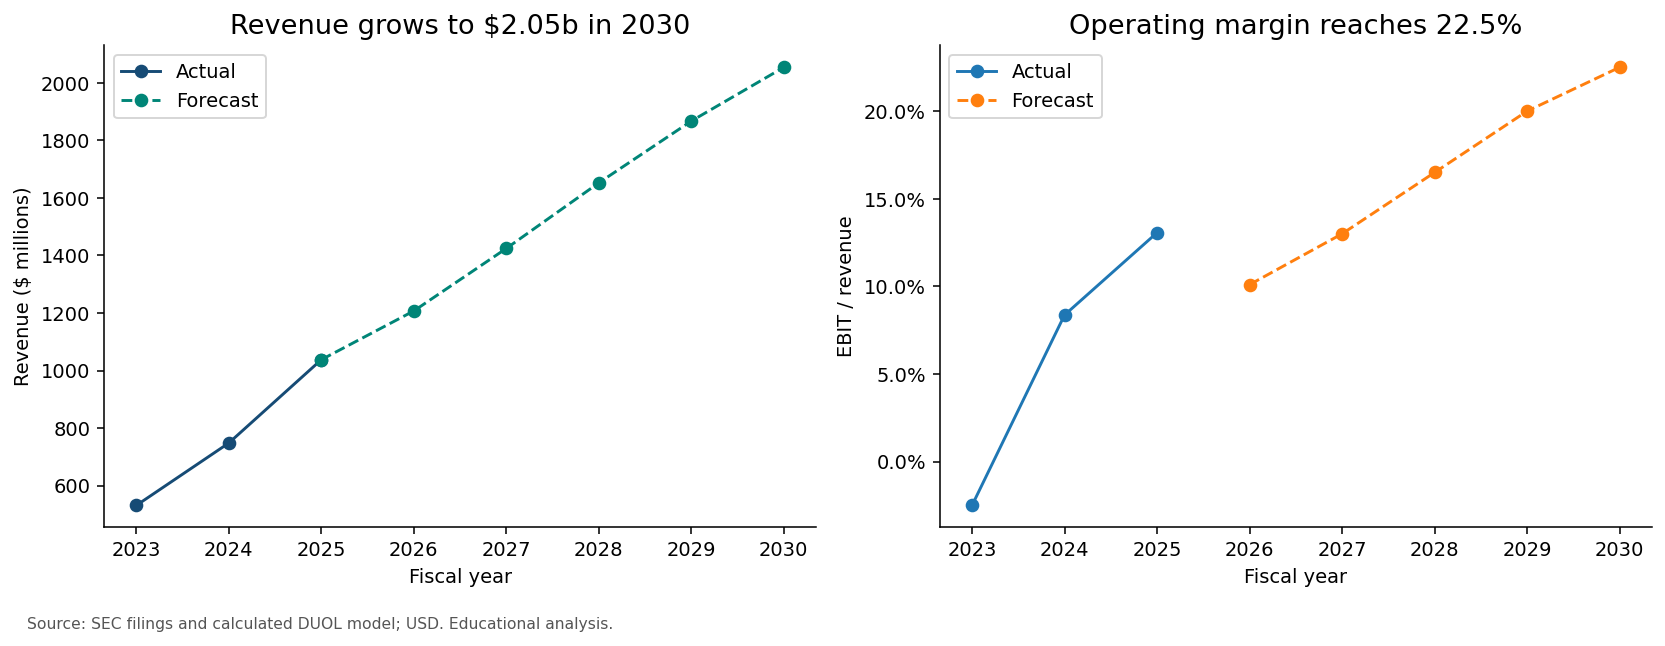

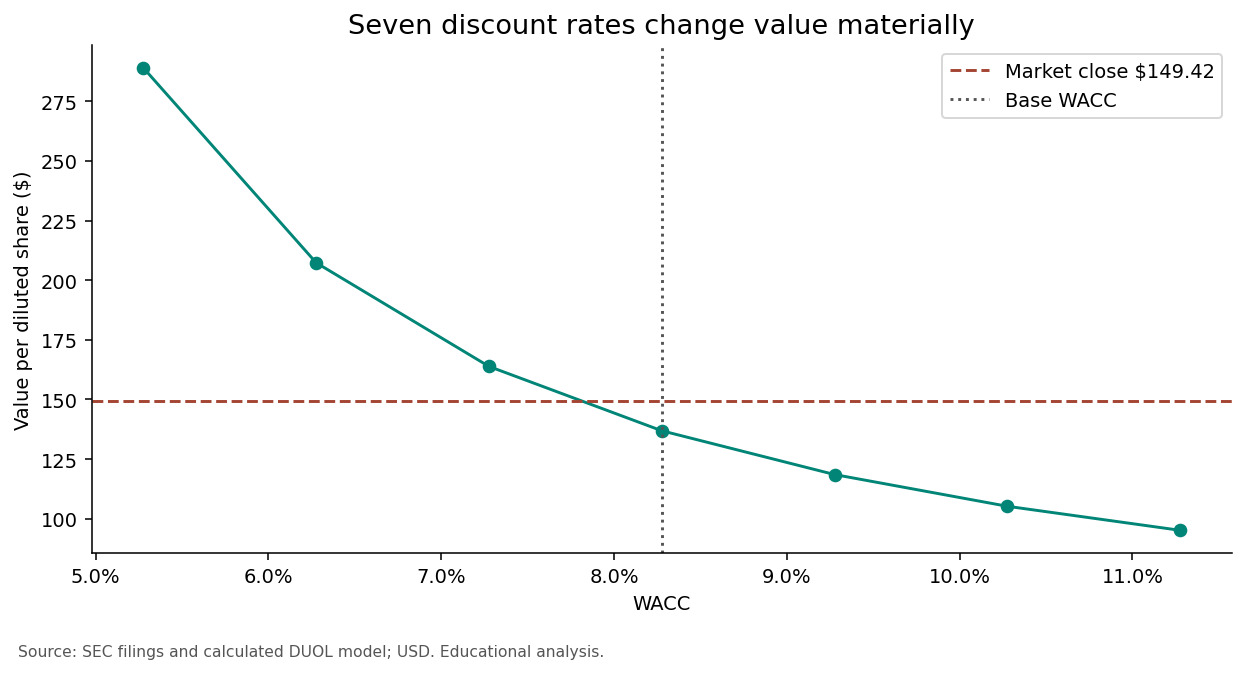

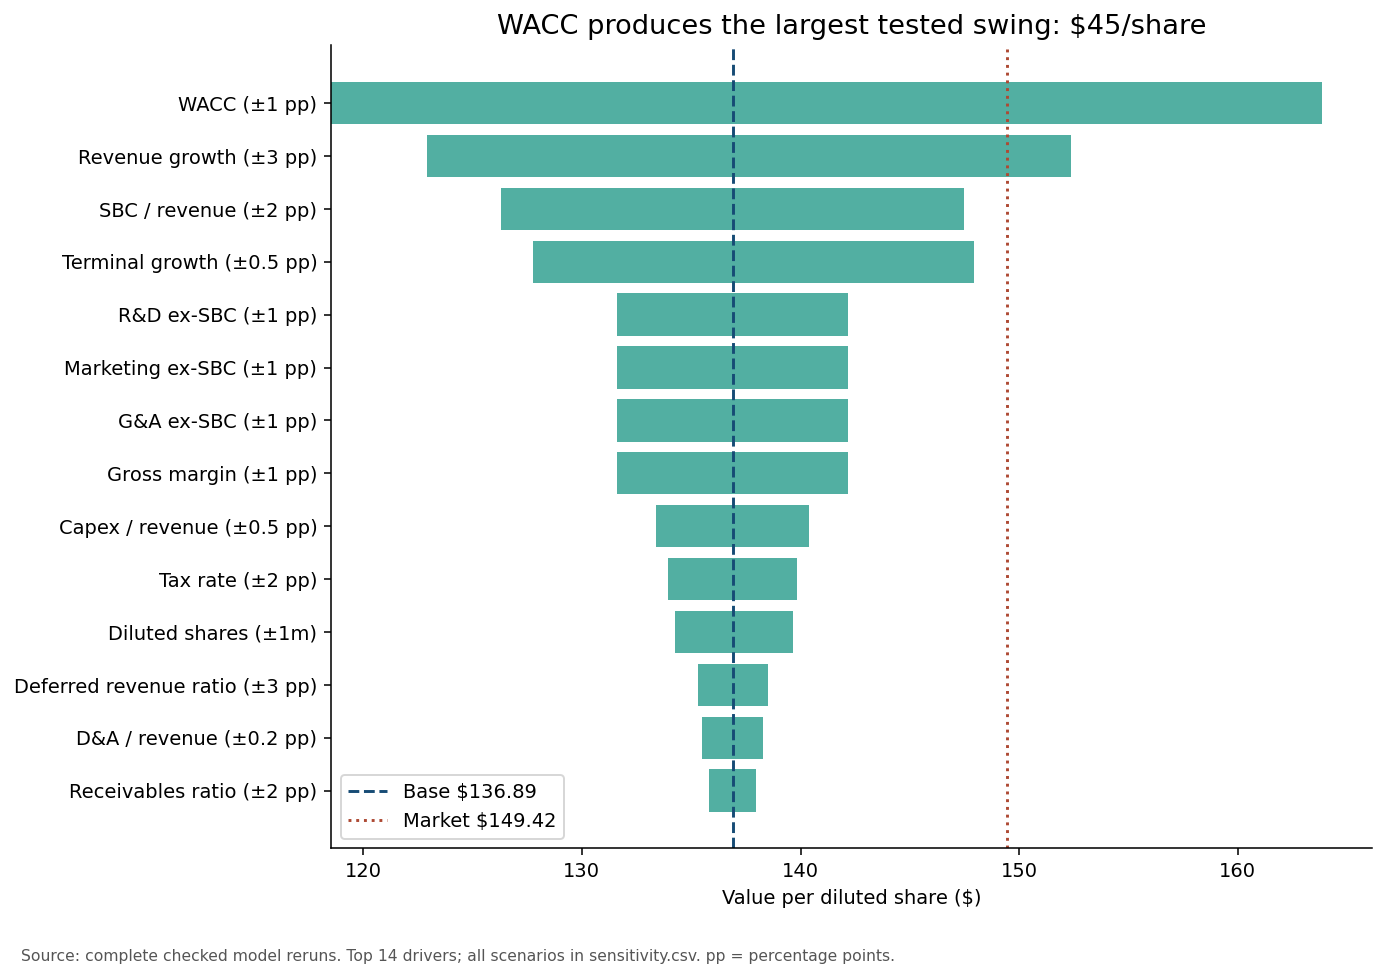

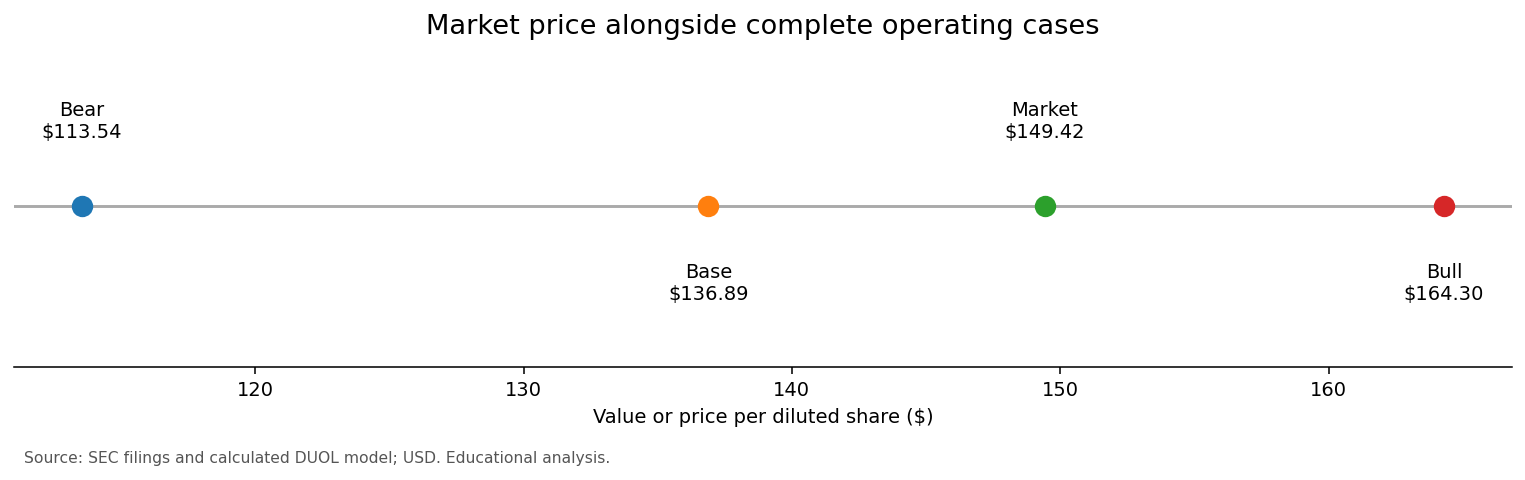

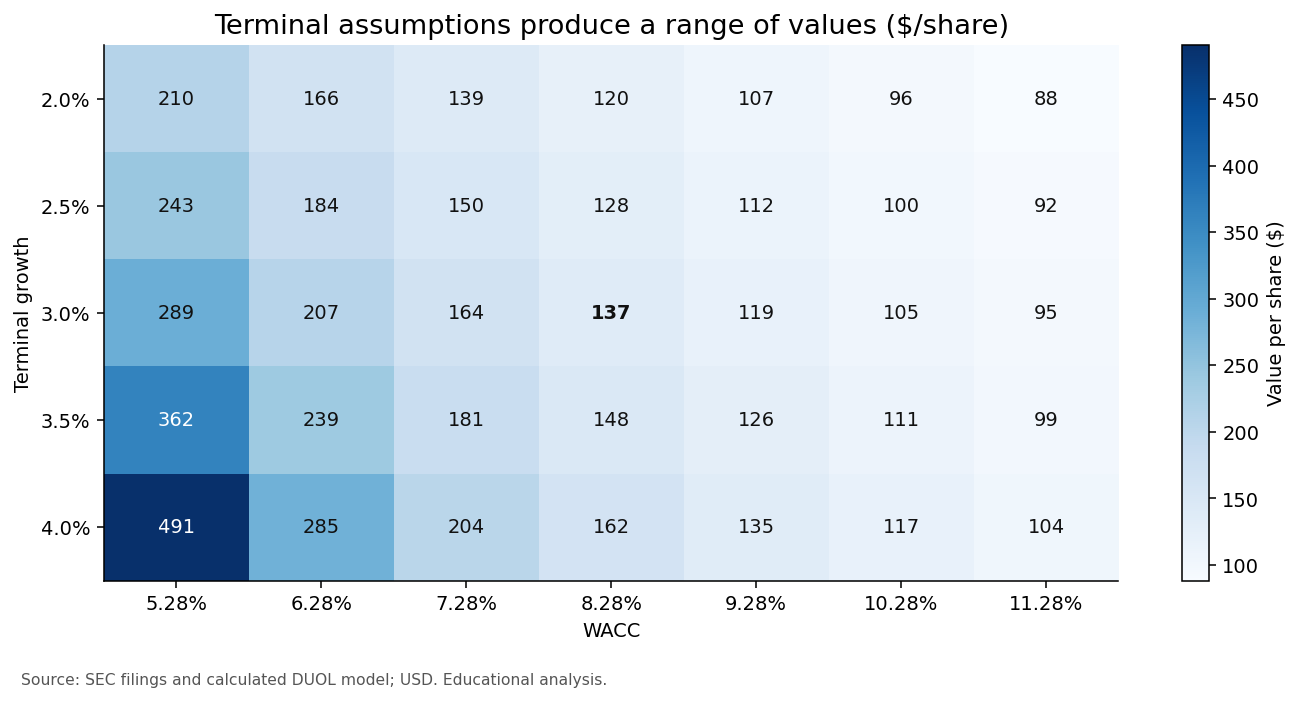

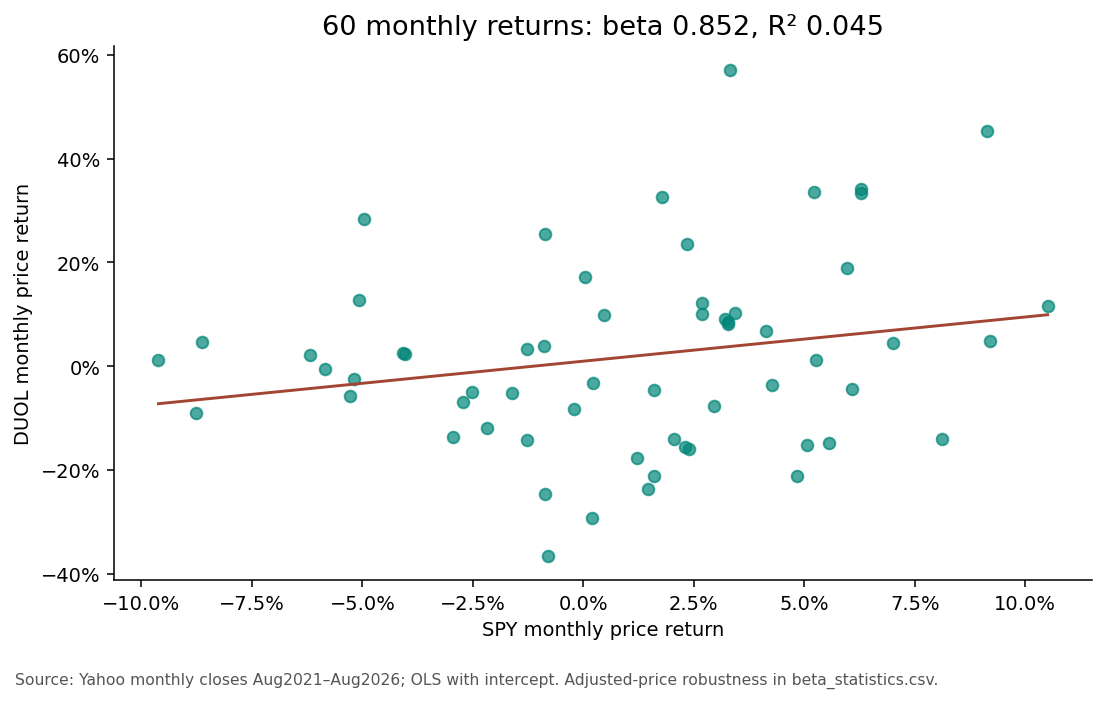

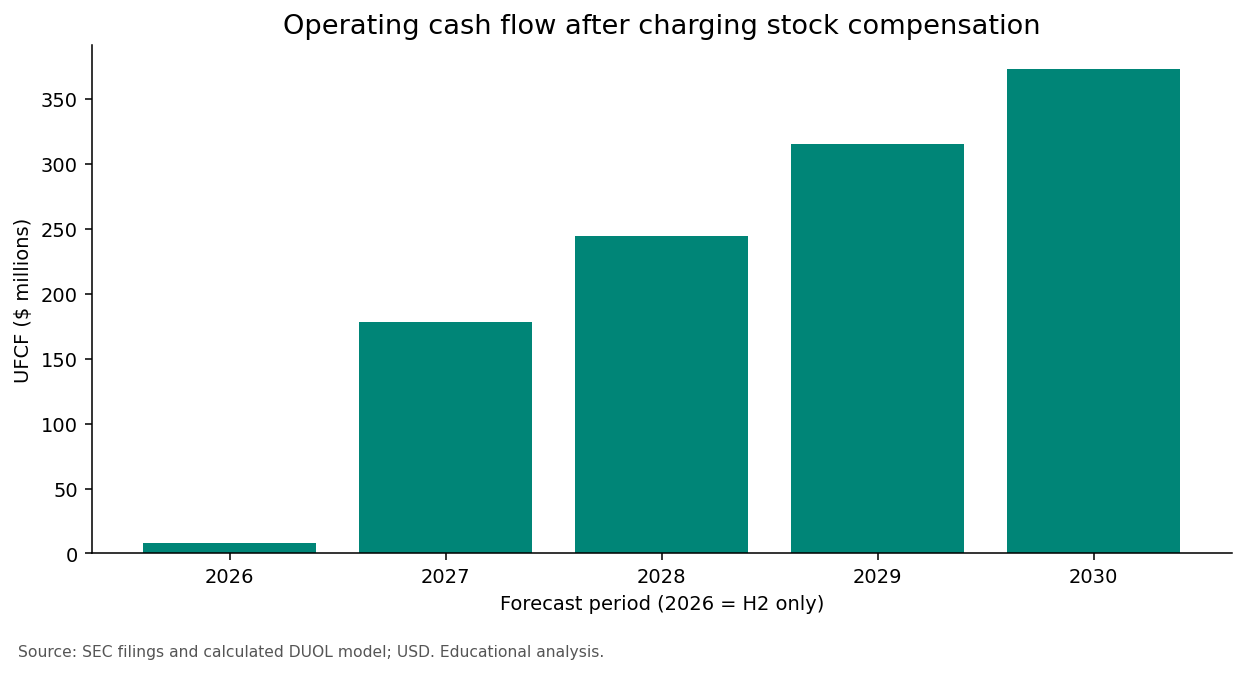

In [21]:
figures = make_charts(history,model,valuation,shocks,rates,named_cases,rate_growth_grid,returns,beta_statistics.iloc[0],market_price,ROOT/"outputs/figures")
for name in figures:
    display(Image(filename=str(ROOT/"outputs/figures"/(name+".png"))))

## 23. Interpretation

The base requires revenue reacceleration after the 2026 reset and operating leverage toward a 22.5% EBIT margin in 2030. It remains below the selected market close. This is a conditional model result, not evidence of mispricing.

Review triggers: gross margin below 70.6%, revenue growth 3 points below the path, or SBC above 17% of revenue. Review the next two filings and update the combined operating case if these persist.

The companion `presentation_brief.md` contains the numerical eight-question defence and clearly labelled simulated sceptic questions. The local driver panel uses this same model. Human oral peer review cannot be performed by the agent.

In [22]:
display(Markdown((ROOT/"LIMITATIONS.md").read_text(encoding="utf8")))

# Limitations and conventions

- Valuation date is September 21, 2026, the latest completed close available when researched September 22. The intraday September 22 quote was not mixed with closing prices.
- Treasury 4.75% and ERP 4.14% are the paired September 1, 2026 Damodaran inputs. Treasury/FRED direct downloads timed out; the model does not claim a September 21 Treasury observation.
- Financial anchor is June 30, 2026. FY2026 combines filed H1 and projected H2. Only 101/184 of H2 economic cash flow remains after September 21. H2 cash generation is spread uniformly for the date bridge (JUDGMENT), despite subscription seasonality. ACT/365 year-end timing uses actual future dates.
- Interim-to-date liquidity is an economic cash estimate: H2 UFCF plus after-tax interest, prorated to the valuation date, less approximately $2.297m known additional repurchases. It charges SBC as a cash-equivalent reserve. It is not an observed September balance sheet; future forecast cash is not added to enterprise value.
- Operating leases remain operating: rent is embedded in expense ratios, accrued current lease obligations in operating liabilities, ROU assets and long-term lease balances held constant. No lease debt is added to WACC or subtracted again in the equity bridge. This is a simplified renewal assumption, not a contractual lease schedule.
- Deferred tax assets, goodwill, tax balances, other long-term assets and investments are held at the interim values (JUDGMENT); no acquisitions, new debt, dividends, FX or investment mark-to-market gains are modeled. Deferred tax assets are not separately added to equity value. Normalized taxes omit possible future tax-asset cash savings.
- Subscription bookings minus revenue approximates deferred-revenue change. Historical balances calibrate the forecast. User counts, subscriber conversion and a revenue-per-year-end-payer proxy explain economics but are not independently compounded into revenue: adding those drivers would introduce unsupported ARPU/churn assumptions.
- SBC is included once in operating expenses and is not added back to UFCF. Accounting CFO adds SBC and credits equity; withholding and repurchases reduce cash/equity. Future share growth is not also imposed on the valuation denominator. The 50.7m company estimate includes outstanding unvested awards; this is a conservative simplified dilution convention, not an option-pricing valuation. Reported basic shares of 46.7m are a June-date market-cap proxy.
- Forecast SBC allocation of 70% R&D, 10% marketing and 20% G&A is JUDGMENT for presentation; total expense drives value. D&A is already inside expense ratios and is allocated between PPE and intangibles by opening carrying value (JUDGMENT). Frozen balances and allocation conventions are disclosed in model_conventions.csv.
- Terminal working capital grows at terminal growth, not the final explicit 10% revenue growth rate. The base implies unusually high incremental returns on measured reinvestment because subscription deferred revenue funds operations and R&D is expensed. Explicit 20% and 30% incremental-ROIC alternatives show this risk.
- Raw beta has low R-squared and a wide confidence interval. SPY adjusted-return beta and Blume beta are reported as alternatives; no dealer peer beta is transplanted to DUOL.
- Full video audiovisual playback was unavailable in the web reader; both full slide decks, spoken notes and caption files were reviewed. The ABG reference uses the exact 17.951349m share count supplied in Lab09 and matches the displayed $291.75 base and rounded scenario answers.
- The course also requires student/partner oral predictions and sceptic discussion. Agent-authored predictions and simulated questions are provided transparently; no human peer review or oral participation is claimed. No GitHub upload or course submission has been performed.


## 24. Final Model Checks

Independent arithmetic/source checks, actual broken-model valuation refusals and final valid-state checks are displayed together. No warning is suppressed to make the model appear valid.

In [23]:
audit = independent_audit(history,interim,model,inputs,valuation,discounting,shocks,implied,prices)
full_broken_tests = broken_tests(model,interim,inputs,history)
display(audit)
display(full_broken_tests[['test','status','valuation_blocked']])
display_checks(run_model_checks(model,interim,inputs,history))
assert all(cell.status == 'PASS' for cell in audit.itertuples())
assert all(full_broken_tests.valuation_blocked)
print('Final valid model retained; all source/arithmetic audit and corruption tests passed.')

,check,status,evidence
0,SEC cross-check 2023 revenue,PASS,"10-K statement cross-check, USD millions"
1,SEC cross-check 2023 ebit,PASS,"10-K statement cross-check, USD millions"
2,SEC cross-check 2023 net_income,PASS,"10-K statement cross-check, USD millions"
3,SEC cross-check 2023 assets,PASS,"10-K statement cross-check, USD millions"
4,SEC cross-check 2023 equity,PASS,"10-K statement cross-check, USD millions"
...,...,...,...
166,Terminal independent arithmetic,PASS,Positive denominator and recomputed terminal c...
167,Bridge independent arithmetic,PASS,Cash + all investments less $100m reserve; zer...
168,Per share independent arithmetic,PASS,50.7m company estimated diluted shares
169,SBC economic expense,PASS,CFO adds SBC; FCFF does not. No annual dilutio...


,test,status,valuation_blocked
0,unlinked cash,PASS,True
1,asset corrupted,PASS,True
2,cash floor,PASS,True
3,NaN,PASS,True
4,cash-flow corrupted,PASS,True
5,fixed-asset roll-forward,PASS,True
6,UFCF corrupted,PASS,True
7,terminal equals WACC,PASS,True
8,terminal exceeds WACC,PASS,True
9,zero shares,PASS,True


FINAL MODEL CHECKS
check_name
Historical balance                          PASS
Historical gross profit                     PASS
Historical EBIT                             PASS
Historical net income                       PASS
Historical assets sum                       PASS
Historical liabilities sum                  PASS
Historical cash bridge                      PASS
Balance sheet                               PASS
Assets total                                PASS
Liabilities total                           PASS
Cash reconciliation                         PASS
PPE roll-forward                            PASS
Intangibles roll-forward                    PASS
Equity roll-forward                         PASS
Income statement                            PASS
CFO construction                            PASS
UFCF construction                           PASS
NWC roll-forward                            PASS
Debt roll-forward                           PASS
Minimum cash                           

## 25. Conclusion

Use the model as a transparent set of testable conditions: guidance anchors the first year, judgment carries the later margin/growth recovery, and the largest sensitivities identify where further research matters. The terminal reinvestment alternative and wide beta uncertainty are material limitations.

All computational work is reproducible with `python duol_valuation/run.py` from DUOL-research. Course submission is via GitHub links to the notebook, markdown and Python/supporting files. The entire local folder is the submission bundle; human partner/oral participation is not represented as completed.

In [24]:
print(f"DUOL base value: ${valuation["value_per_share"]:.2f}; market close: ${market_price:.2f}; WACC: {valuation["wacc"]:.4%}; all required model checks PASS.")

DUOL base value: $136.89; market close: $149.42; WACC: 8.2764%; all required model checks PASS.
